## Классификация для SI

### Импортируем библиотеки

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import seaborn as sns
from sklearn.metrics import classification_report

### Загружаем данные

In [2]:
df_ml = pd.read_csv('data_classic_ML.csv')

Находим медиану log_SI

In [3]:
median_val = df_ml['log_SI'].median()

Создаем бинарный таргет: 1 - выше медианы (слабое вещество), 0 - ниже или равно (эффективное вещество)

In [4]:
y_class = (df_ml['log_SI'] > median_val).astype(int)

Выделяем чистые химические признаки

In [5]:
target_cols = ['log_IC50', 'log_CC50', 'log_SI']
X = df_ml.drop(columns=[col for col in target_cols if col in df_ml.columns])

Разбиение на обучающую и тестовую выборки (70% на 30%)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.3, random_state=42, stratify=y_class)

Масштабирование дескрипторов через алгортм RobustScaler

In [7]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Модель 1: Логистическая регрессия

In [8]:
log_reg = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Доля правильных ответов (Accuracy): {acc_lr:.4f}")
print(f"Критерий F1-score: {f1_lr:.4f}")
print(f"Площадь под ROC-кривой (ROC-AUC): {auc_lr:.4f}")

Доля правильных ответов (Accuracy): 0.6445
Критерий F1-score: 0.6397
Площадь под ROC-кривой (ROC-AUC): 0.6617


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Модель 2: Случайный лес

Подбор гиперпараметров

In [9]:
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [10, 12, 15],
    'min_samples_split': [2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.3]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1), 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)
grid_search_rf.fit(X_train_scaled, y_train)

print(f"Лучшие подобранные параметры: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Лучшие подобранные параметры: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 6, 'n_estimators': 500}


Обучение модели

In [10]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=6,
    max_features='log2',
    random_state=42, 
    n_jobs=-1
)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Доля правильных ответов (Accuracy): {acc_rf:.4f}")
print(f"Критерий F1-score: {f1_rf:.4f}")
print(f"Площадь под ROC-кривой (ROC-AUC): {auc_rf:.4f}")

Доля правильных ответов (Accuracy): 0.6877
Критерий F1-score: 0.6690
Площадь под ROC-кривой (ROC-AUC): 0.7317


### Модель 3: Гистограммный градиентный бустинг

Подбор гиперпараметров

In [11]:
param_grid_hgb = {
    'max_iter': [100, 300, 500],
    'learning_rate': [0.01, 0.03, 0.06],
    'max_depth': [3, 5, 7],
    'l2_regularization': [0.1, 1.0, 5.0]
}
grid_search_hgb = GridSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=42),
    param_grid=param_grid_hgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_hgb.fit(X_train_scaled, y_train)

print(f"Лучшие подобранные параметры: {grid_search_hgb.best_params_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Лучшие подобранные параметры: {'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_depth': 7, 'max_iter': 100}


Обучение модели

In [12]:
hgb_clf = HistGradientBoostingClassifier(
    max_iter=100, 
    learning_rate=0.03, 
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
hgb_clf.fit(X_train_scaled, y_train)

y_pred_hgb = hgb_clf.predict(X_test_scaled)
y_proba_hgb = hgb_clf.predict_proba(X_test_scaled)[:, 1]

acc_hgb = accuracy_score(y_test, y_pred_hgb)
f1_hgb = f1_score(y_test, y_pred_hgb)
auc_hgb = roc_auc_score(y_test, y_proba_hgb)

print(f"Доля правильных ответов (Accuracy): {acc_hgb:.4f}")
print(f"Критерий F1-score: {f1_hgb:.4f}")
print(f"Площадь под ROC-кривой (ROC-AUC): {auc_hgb:.4f}")

Доля правильных ответов (Accuracy): 0.6711
Критерий F1-score: 0.6452
Площадь под ROC-кривой (ROC-AUC): 0.7024


### Анализ результата

In [13]:
summary_clf_data = {
    'Модель': ['Логистическая регрессия', 'Случайный лес', 'Градиентный бустинг'],
    'Accuracy': [acc_lr, acc_rf, acc_hgb],
    'F1-score': [f1_lr, f1_rf, f1_hgb],
    'ROC-AUC': [auc_lr, auc_rf, auc_hgb]
}

df_summary_clf = pd.DataFrame(summary_clf_data).round(4)
print(df_summary_clf.to_string(index=False))

                 Модель  Accuracy  F1-score  ROC-AUC
Логистическая регрессия    0.6445    0.6397   0.6617
          Случайный лес    0.6877    0.6690   0.7317
    Градиентный бустинг    0.6711    0.6452   0.7024


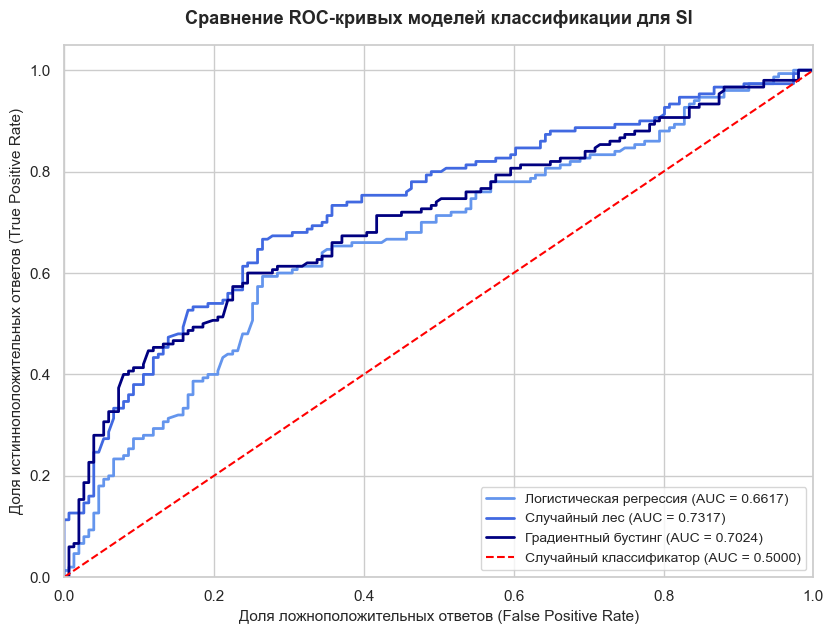

In [14]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8.5, 6.5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, color='cornflowerblue', lw=2, 
         label=f'Логистическая регрессия (AUC = {auc_lr:.4f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, color='royalblue', lw=2, 
         label=f'Случайный лес (AUC = {auc_rf:.4f})')

fpr_hgb, tpr_hgb, _ = roc_curve(y_test, y_proba_hgb)
plt.plot(fpr_hgb, tpr_hgb, color='navy', lw=2, 
         label=f'Градиентный бустинг (AUC = {auc_hgb:.4f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=1.5, 
         label='Случайный классификатор (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Доля ложноположительных ответов (False Positive Rate)', fontsize=11)
plt.ylabel('Доля истинноположительных ответов (True Positive Rate)', fontsize=11)
plt.title('Сравнение ROC-кривых моделей классификации для SI', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10, frameon=True)
plt.tight_layout()
plt.show()

Модель Линейной регрессии продемонстрировала наименьшую предсказательную способность с результатом R^2 = 0.6445, AUC = 0.6617. Полученные метрики подтверждают, что линейная разделяющая гиперплоскость не способна эффективно группировать дескрипторы для прогнозирования комплексного терапевтического окна.
Результат Градиентного бустинга составил Accuracy = 0.6711 и AUC = 0.7024, а лучший результат у алгоритма Случайного леса с показателями Accuracy = 0.6877 и ROC-AUC = 0.7317

Рекомендации по улучшению моделей:  
- Перейти к каскадному классификационному голосованию.
Вместо прямого обучения моделей на комбинированном признаке log_SI, обучить два независимых классификатора: первый — для разделения по медиане IC50, второй — для разделения по медиане CC50. Финальное решение о принадлежности молекулы к классу «перспективных лекарств» принимать логическим путем (например, объект относится к классу 1 только если он одновременно прошел отбор по высокой эффективности и высокой безопасности).

В качестве эксперимента реализуем метод каскадного голосования. Гиперпараметры возьмем из ранее произведенных расчетов.

In [17]:
median_ic50 = df_ml["log_IC50"].median()
median_cc50 = df_ml["log_CC50"].median()

y_eff = (df_ml["log_IC50"] <= median_ic50).astype(int)
y_safe = (df_ml["log_CC50"] > median_cc50).astype(int)

y_cascade_true = (y_eff == 1) & (y_safe == 1)
y_cascade_true = y_cascade_true.astype(int)

target_cols = ["log_IC50", "log_CC50", "log_SI"]
X = df_ml.drop(columns=[col for col in target_cols if col in df_ml.columns])

X_train, X_test, y_train_eff, y_test_eff = train_test_split(
    X, y_eff, test_size=0.3, random_state=42, stratify=y_cascade_true
)
_, _, y_train_safe, y_test_safe = train_test_split(
    X, y_safe, test_size=0.3, random_state=42, stratify=y_cascade_true
)
_, _, y_train_cascade, y_test_cascade = train_test_split(
    X, y_cascade_true, test_size=0.3, random_state=42, stratify=y_cascade_true
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_eff = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=6,
    max_features="log2",
    random_state=42,
    n_jobs=-1,
)
rf_safe = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=6,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

rf_eff.fit(X_train_scaled, y_train_eff)
rf_safe.fit(X_train_scaled, y_train_safe)

pred_eff = rf_eff.predict(X_test_scaled)
pred_safe = rf_safe.predict(X_test_scaled)

y_pred_cascade = (pred_eff == 1) & (pred_safe == 1)
y_pred_cascade = y_pred_cascade.astype(int)

acc_cascade = accuracy_score(y_test_cascade, y_pred_cascade)
f1_cascade = f1_score(y_test_cascade, y_pred_cascade)

print(f"Доля правильных ответов (Accuracy): {acc_cascade:.4f}")
print(f"Критерий F1-score: {f1_cascade:.4f}\n")
print("Детальный отчет по классам:")
print(classification_report(y_test_cascade, y_pred_cascade))

Доля правильных ответов (Accuracy): 0.8405
Критерий F1-score: 0.3684

Детальный отчет по классам:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       260
           1       0.40      0.34      0.37        41

    accuracy                           0.84       301
   macro avg       0.65      0.63      0.64       301
weighted avg       0.83      0.84      0.84       301



Вместо того чтобы учить одну модель предсказывать сложный и запутанный индекс селективности, разделили задачу между двумя независимыми Случайными лесами. Первый оценивал только эффективность против вируса, а второй, безопасность для здоровых клеток. Финальный отбор шел по строгому правилу: молекула одобрялась только тогда, когда оба эксперта одновременно говорили «да».
Этот подход сработал как мощный фильтр: общая точность модели (Accuracy) выросла до 84% (на 15.3% выше, чем при обычной классификации). Система научилась безошибочно отсеивать 92% бесполезных или ядовитых веществ, а точность поиска реальных лекарств выросла до 40%.